In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [3]:
df = pd.read_csv('../expanded_water_usage.csv')
df.head()

,timestamp,water_usage
0,2010-01-01 00:00:00,5.524019
1,2010-01-01 01:00:00,5.400714
2,2010-01-01 02:00:00,5.308263
3,2010-01-01 03:00:00,5.308263
4,2010-01-01 04:00:00,5.924607


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Set the index and enforce hourly frequency
ts = df.set_index('timestamp')['water_usage'].asfreq('H')
ts = ts.dropna()  # drop missing values if any


/tmp/ipykernel_365747/1478613247.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts = df.set_index('timestamp')['water_usage'].asfreq('H')


Original series stationarity test:


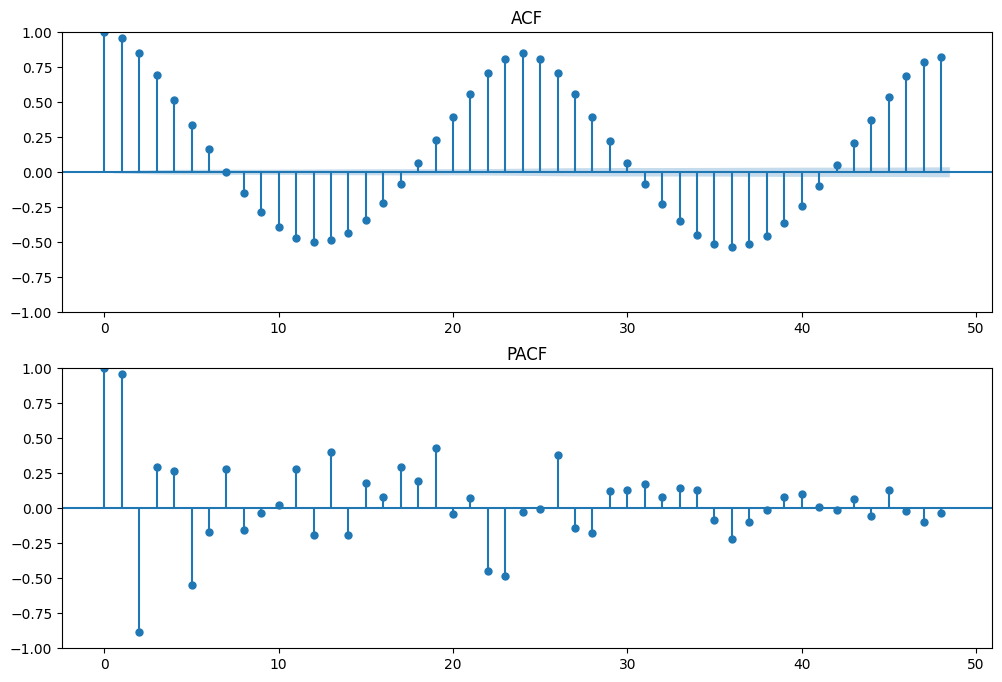

ADF Statistic: -11.7079
p-value: 0.0000
Data is stationary (reject H0)


In [5]:
def test_stationarity(series):
    """Plot ACF, PACF and run the Augmented Dickey-Fuller test."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(series, lags=48, ax=ax1, title='ACF')
    plot_pacf(series, lags=48, ax=ax2, title='PACF', method='ywm')
    plt.show()
    
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Data is stationary (reject H0)")
    else:
        print("Data is non-stationary (fail to reject H0)")

# Test stationarity on original series
print("Original series stationarity test:")
test_stationarity(ts)

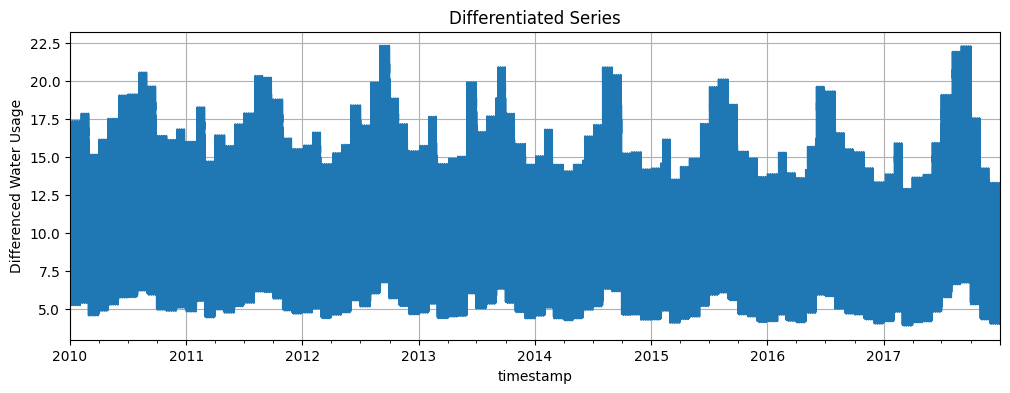

In [6]:
plt.figure(figsize=(12, 4))
ts.plot(title='Differentiated Series')
plt.ylabel('Differenced Water Usage')
plt.grid(True)
plt.show()



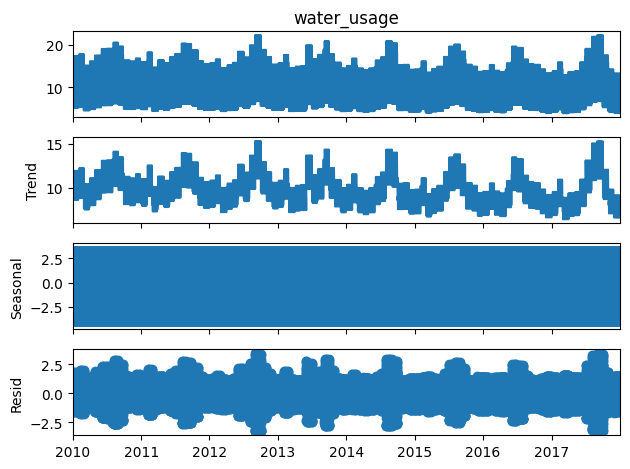

: 

In [ ]:
decomp_result = seasonal_decompose(ts, model='additive', period=)
decomp_result.plot()
plt.show()


In [ ]:
    print("Fitting auto_arima on original series:")
    stepwise_model = auto_arima(ts,
                                start_p=0, max_p=3,
                                start_q=0, max_q=3,
                                d=1,                   # non-seasonal differencing
                                seasonal=True,
                                m=24,                  # daily seasonality (24 hours)
                                start_P=0, max_P=2,
                                start_Q=0, max_Q=2,
                                D=1,                   # seasonal differencing
                                trace=True,
                                error_action='ignore',  
                                suppress_warnings=True,
                                stepwise=True)

    print(stepwise_model.summary())


Fitting auto_arima on original series:
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[24]             : AIC=61944.997, Time=25.02 sec
